# Methods for phase extraction from respiration data

To obtain a circular representation of from time series there are four different methods implemented: `phase_hilbert()`, `phase_onepoint()`, `phase_twopoint()` and `phase_threepoint()` which all have been used in previous research. 

Choosing between these methods has implications for both the interpretation of individual phase angles and the statistical analyses that can subsequently be performed. 



In [1]:
import numpy as np
from pyriodic.preproc import RawSignal
from pyriodic.viz import plot_phase_diagnostics

import matplotlib.pyplot as plt


In [2]:
# load data
from bioread import read_file
data = read_file("../../data/respiration/example.acq")

# extract respiration channel and sampling rate
sfreq = data.samples_per_second
print(f"Sampling rate: {sfreq} Hz")

t, resp_ts = data.time_index, data.channels[0].data
print(f"Data length: {len(resp_ts)/sfreq/60:.2f} minutes")

# events
events_path = "../../data/respiration/example_events.npy"
with open(events_path, "rb") as f:
    events = np.load(f)


# for quick testing, we can use a subset of the data
start_sample = events[0, 0] - 1000  # start 1000 samples before the first event

# subtract start sample from events (the first column)
events[:, 0] -= start_sample

duration_samples = int(sfreq * 60 * 10)  # 10 minutes
resp_ts = resp_ts[start_sample:start_sample + duration_samples]

# only keep events that are within the range of the new resp_ts
events = events[events[:, 0] < len(resp_ts)]

# initialise RawSignal object
raw = RawSignal(resp_ts, fs=sfreq)


Sampling rate: 1000.0 Hz
Data length: 48.36 minutes


In [3]:
# initial preprocessing: bandpass filter, smoothing, and z-scoring
raw.filter_bandpass(low=0.1, high=1.0)
raw.smoothing(window_size=500) 
raw.zscore()

## Different methods

Broadly, methods for reconstructing instantaneous phase can be divided into two categories:

1. **Landmark-based methods:**  Phase is defined relative to identifiable landmarks in the signal, such as a spike in neural oscillations or the peaks and troughs of a respiratory signal. Three such methods are implemented in the \lstinline{Pyriodic}; `phase_onepoint()`, `phase_twopoint()` and `phase_threepoint()`. All of these methods rely on identifying peaks of time series data. As different types of data has different characteristics, the user can specify `distance` and `prominence` parameters for the default peak finder function `scipy.signal.find_peaks()`. You can also specify a custom peak finder function by providing a callable to the `peak_finder` argument.

2. **Continuous phase estimation methods.** Rather than relying on discrete landmarks, these approaches transform the time series into a continuous complex-valued representation from which instantaneous phase can be extracted at every time point. This is implemented using the Hilbert transform through the function `phase_hilbert()`.

### Landmark-based methods


In [4]:
PA_onepoint, peaks_onepoint = raw.phase_onepoint(prominence=0.1)

In [5]:
PA_twopoint, peaks_twopoint, troughs_twopoint = raw.phase_twopoint(prominence=0.1)


In [6]:
PA_threepoint, peaks_threepoint, troughs_threepoint = raw.phase_threepoint()

### Continuous phase estimation methods

In [7]:
PA_hilbert = raw.phase_hilbert()

### Comparison of methods
Let's start by ccomparing the phase angle time series extracted using the different methods. The following figure shows the phase angle time series extracted using the one-point, two-point and Hilbert methods. The phase angle time series are shown for a 40 second window of data starting at 300 seconds. The peaks and troughs identified by the two-point method are also shown.

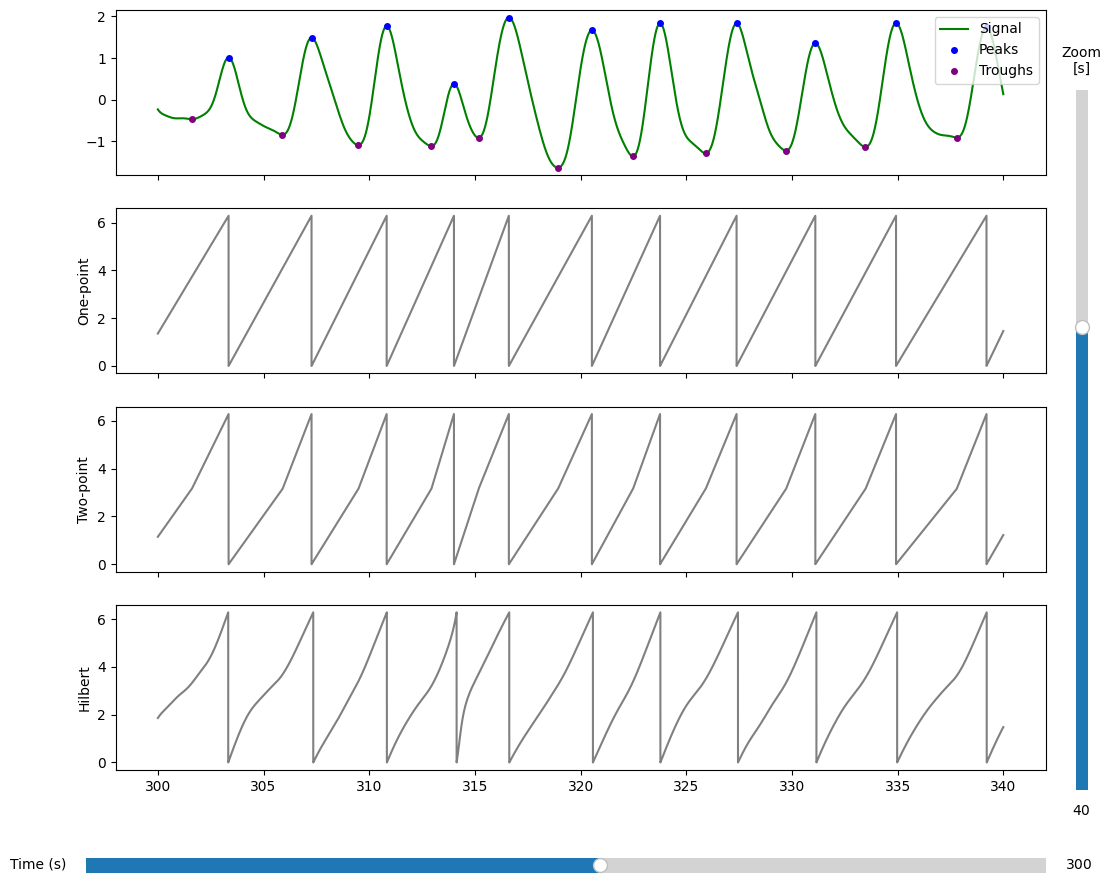

(<Figure size 1200x1000 with 6 Axes>,
 array([<Axes: >, <Axes: ylabel='One-point'>, <Axes: ylabel='Two-point'>,
        <Axes: ylabel='Hilbert'>], dtype=object))

In [12]:
plot_phase_diagnostics(
    {"One-point": PA_onepoint, "Two-point": PA_twopoint, "Hilbert": PA_hilbert},
    start = 300,
    window_duration = 40,
    fs = raw.fs,
    data = raw.ts,
    peaks=peaks_twopoint, # plotting the peaks and troughs from the two-point method. Same peaks are identified by the one-point method. 
    troughs=troughs_twopoint 
)

We can also look at the distribution of phase angles extracted using the different methods. The following figure shows the distribution of phase angles extracted using the one-point, two-point and Hilbert methods.

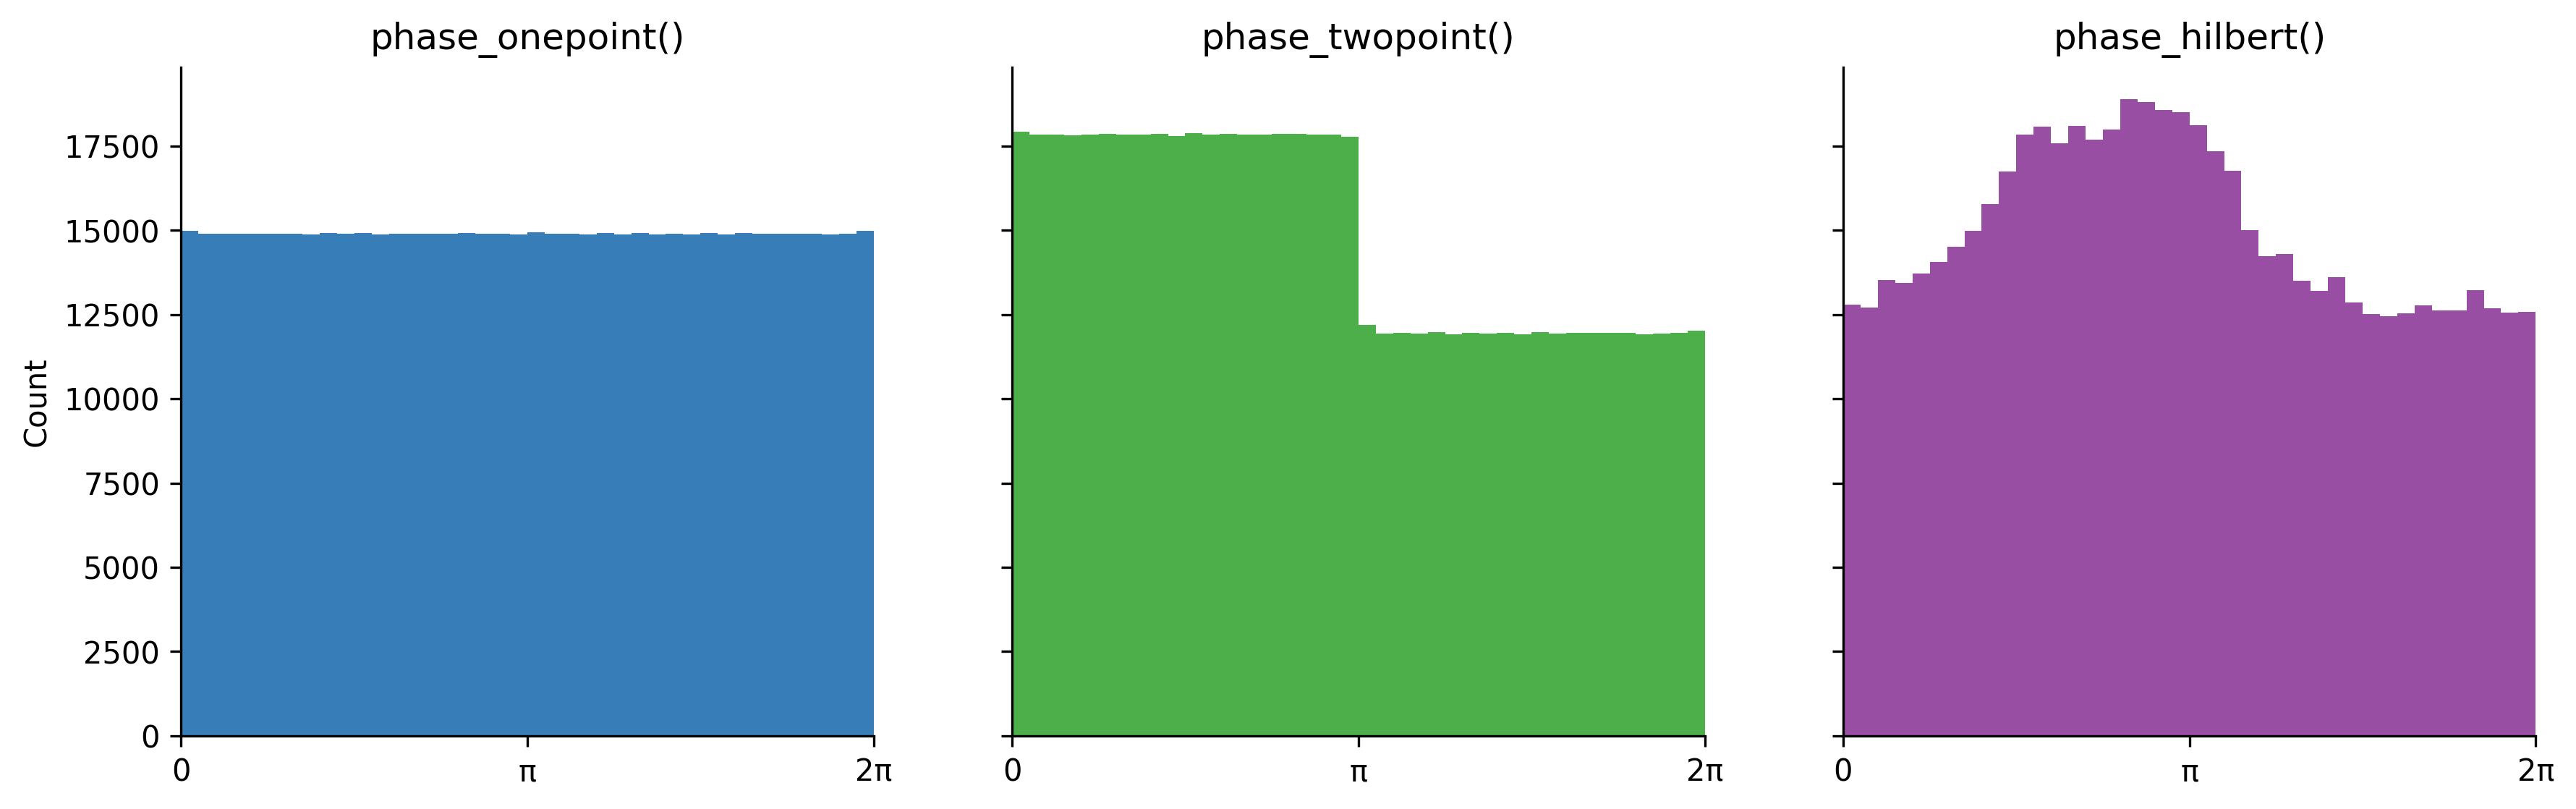

In [11]:
# histogram of phase values
phase_values = [PA_onepoint, PA_twopoint, PA_hilbert]
labels = ['phase_onepoint()', 'phase_twopoint()', 'phase_hilbert()']

fig, axes = plt.subplots(1, len(phase_values), figsize=(14, 4), sharey=True, sharex=True, dpi=300)

cmap = plt.get_cmap('Set1')
colors = [cmap(i+1) for i in range(len(phase_values))]

for phase, label, ax, color in zip(phase_values, labels, axes, colors):

    ax.hist(phase, bins=40, color=color,)
    ax.set_title(label)
    ax.set_xlim(0, 2*np.pi)

axes[0].set_xticks([0, np.pi, 2*np.pi])
axes[0].set_xticklabels(['0', 'π', '2π'])
axes[0].set_ylabel('Count')

for ax in axes.flat:
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)


In [10]:
# proportion of phase values in 0-pi and pi-2pi ranges
for phase, label in zip(phase_values, labels):
    prop_0_pi = np.sum((phase >= 0) & (phase < np.pi)) / len(phase)
    prop_pi_2pi = np.sum((phase >= np.pi) & (phase < 2*np.pi)) / len(phase)
    print(f"{label}: Proportion in [0, π): {prop_0_pi:.3f}, Proportion in [π, 2π): {prop_pi_2pi:.3f}")

phase_onepoint(): Proportion in [0, π): 0.497, Proportion in [π, 2π): 0.497
phase_twopoint(): Proportion in [0, π): 0.595, Proportion in [π, 2π): 0.399
phase_hilbert(): Proportion in [0, π): 0.541, Proportion in [π, 2π): 0.459
